In [1]:
from neuromodes import EigenSolver
from neuromodes.io import fetch_surf
from neuromodes.waves import _analytical_fc
import numpy as np
import matplotlib.pyplot as plt

In [5]:
# Params
n_modes = 500
r = 17.4
gamma = 116.0
n_timepoints = [100, 500, 1000, 5000, 10000, 50000]
dt = 0.01
seed = 0

In [3]:
surf, medmask = fetch_surf(density='4k')
solver = EigenSolver(surf, medmask).solve(n_modes, seed=seed)

In [4]:
# Try analytical solution for FC
a_fc = _analytical_fc(solver.emodes, solver.evals, r, gamma)

In [6]:
sim_ts = solver.simulate_waves(nt=max(n_timepoints), seed=seed, r=r, gamma=gamma, dt=dt)

In [7]:
mses = []
fcs = []
for nt in n_timepoints:
    sim_fc = np.corrcoef(sim_ts[:, :nt])
    fcs.append(sim_fc)
    mse = np.mean((sim_fc - a_fc)**2)
    mses.append(mse)

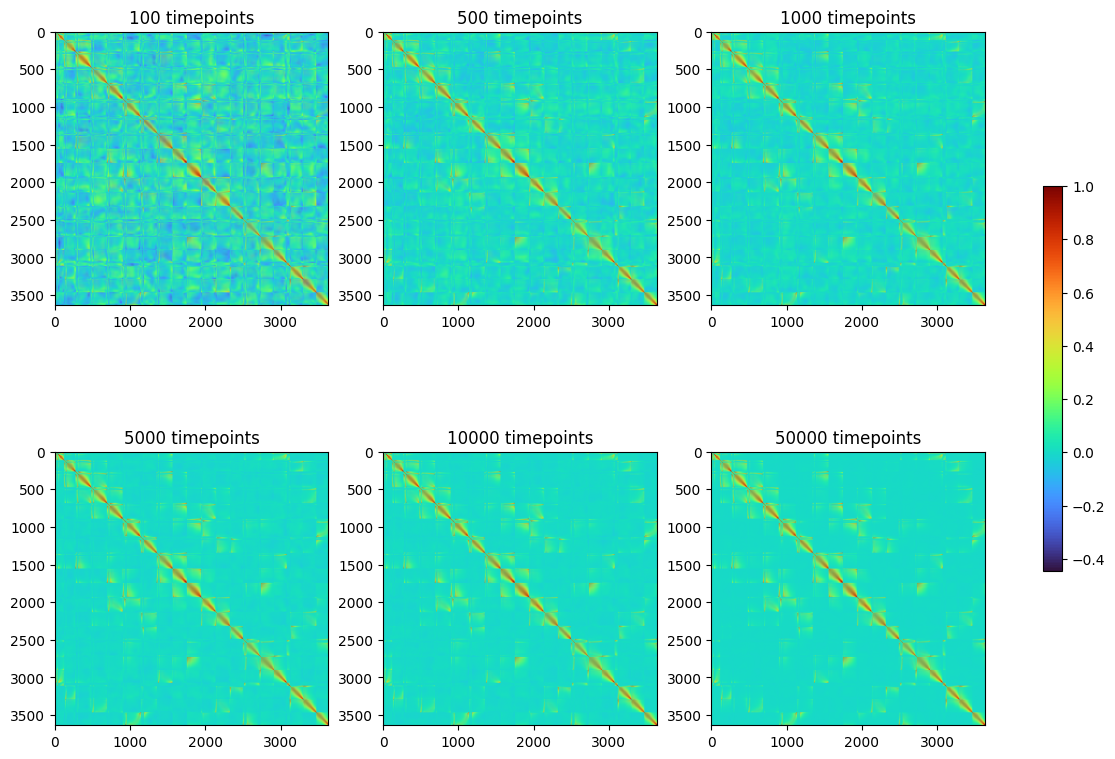

In [8]:
# plot FC matrix for each n_timepoints
vmin = min(np.min(fc) for fc in fcs)
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for ax, sim_fc, nt in zip(axes.flatten(), fcs, n_timepoints):
    im = ax.imshow(sim_fc, cmap='turbo', vmin=vmin, vmax=1)
    ax.set_title(f'{nt} timepoints')
fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.5)
plt.show()

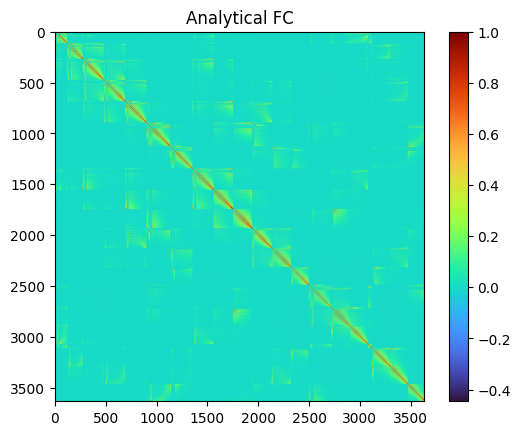

In [9]:
plt.imshow(a_fc, cmap='turbo', vmin=vmin, vmax=1)
plt.colorbar()
plt.title('Analytical FC')
plt.show()

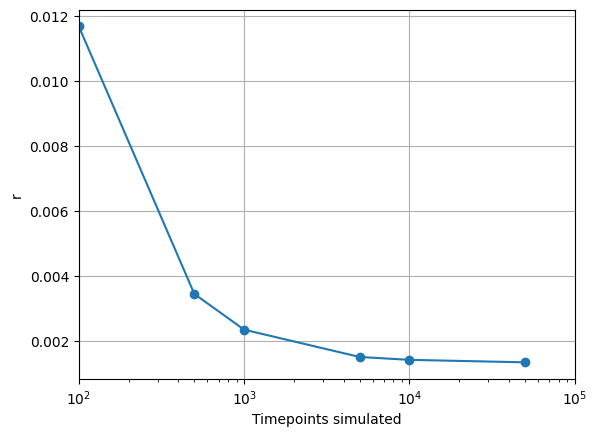

In [10]:
plt.plot(n_timepoints, mses, marker='o')
plt.xscale('log')
plt.xlim(10**2, 10**5)
plt.xlabel('Timepoints simulated')
plt.ylabel('r')
plt.grid()
plt.show()